# Prediksi Prioritas *Follow-up Repeat Order* — SPARC 2026

## Kerangka Berpikir (Problem Framing)

Dataset bersifat **transaksional**: satu baris = satu transaksi pembelian kendaraan, dan satu pelanggan
(`Customer ID`) dapat muncul lebih dari satu kali. Tidak tersedia label target secara eksplisit, sehingga
target **kami rekayasa (feature engineering target)** dari perilaku pembelian:

> **`is_repeat` = 1** jika seorang pelanggan tercatat melakukan **lebih dari satu transaksi**, dan **0** jika hanya sekali.

Agar model dapat dipakai untuk *follow-up* di dunia nyata (memprediksi sebelum pelanggan kembali), setiap
pelanggan diwakili oleh **karakteristik transaksi pertamanya** (informasi yang sudah diketahui pada titik kontak awal).
Dengan demikian model mempelajari: *"berdasarkan profil transaksi pertama, seberapa besar peluang pelanggan ini akan kembali?"*

## Alur Pipeline (End-to-End)

1. **Pemuatan Data** — langsung dari tautan GitHub resmi kompetisi.
2. **Pembersihan Data** — standardisasi tipe, parsing nilai Rupiah/tanggal, penanganan anomali & nilai tidak valid.
3. **Pembentukan Target** — definisi `is_repeat` di level pelanggan (dibuat **sebelum** pembersihan fitur untuk mencegah kebocoran/label yang berubah).
4. **Exploratory Data Analysis (EDA)** — analisis deskriptif + hubungan tiap fitur terhadap perilaku repeat.
5. **Feature Engineering** — pembuatan fitur rasio, transformasi log, dan *frequency encoding*.
6. **Feature Encoding & Preprocessing** — pipeline `ColumnTransformer` (imputasi, scaling, one-hot).
7. **Pemodelan** — baseline → Logistic Regression → Random Forest → LightGBM, dengan penanganan *class imbalance* & *hyperparameter tuning*.
8. **Evaluasi & Interpretasi** — metrik yang tepat untuk data tidak seimbang, *threshold tuning*, & *feature importance*.
9. **Output Bisnis** — tabel *lift*/*gains* dan daftar prioritas *follow-up* sebagai jawaban langsung atas tujuan bisnis.

> **Catatan reprodusibilitas:** seluruh proses acak (pembagian data, inisialisasi model, training, tuning)
> menggunakan `SEED = 42` sehingga hasil konsisten saat dijalankan ulang.

## 0. Setup & Konfigurasi

Mengimpor pustaka yang dibutuhkan dan menetapkan `SEED` global. Semua dependensi merupakan pustaka
standar ekosistem *data science* Python (`pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `lightgbm`).

In [1]:
# Instalasi dependensi (aktifkan bila dijalankan di lingkungan bersih, mis. Google Colab)
# !pip install -q pandas numpy scikit-learn matplotlib seaborn lightgbm

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Reprodusibilitas: satu sumber kebenaran untuk seluruh proses acak ---
SEED = 42
np.random.seed(SEED)

# --- Konfigurasi tampilan ---
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.autolayout"] = True

print("Setup selesai. SEED =", SEED)

Setup selesai. SEED = 42


## 1. Pemuatan Data

Sesuai ketentuan kompetisi, data **hanya** diimpor melalui tautan GitHub resmi. Seluruh kolom sengaja
dibaca sebagai teks (`dtype=str`) agar **kami yang mengendalikan proses parsing** (nilai Rupiah, tanggal,
dan kode kategori) — bukan pandas yang menebak tipe secara otomatis, sehingga menghindari salah interpretasi.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/micelll/SPARC-2026/main/SPARC_dataset.csv"

# Baca semua kolom sebagai string agar parsing terkontrol penuh
df_raw = pd.read_csv(DATA_URL, dtype=str, keep_default_na=True)

print("Dimensi data mentah :", df_raw.shape)
print("Jumlah kolom        :", df_raw.shape[1])
df_raw.head()

Dimensi data mentah : (319978, 28)
Jumlah kolom        : 28


,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Tgl Lahir,Agama,Pekerjaan,umur,dp aktual,cicilan,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,DLR group,tgl cetak,tgl mohon,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2,12756,4,3,2,1992-03-03 0:00:00,1,2e,27,Rp 21.000.000,Rp 8.600.000,MC,Balikpapan,BREEZ SERIES,2 - 3 juta,6471,AT LOW,HN,18685000,NaN,NaN,NaN,02-01-2019,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2,733,1,1,2,1991-04-27 0:00:00,1,2b,28,87800000,20600000,MC,Balikpapan,BREEZ SERIES,3 jt up,6471,AT LOW,HN,18685000,NaN,NaN,NaN,02012019,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1,733,N,N,2,1982-01-04 0:00:00,1,4b,37,Rp 0,Rp 0,MH,Balikpapan,SCOOTY SERIES,kurang 1 juta,6471,AT MID,HR,20775000,NaN,NaN,NaN,02012019,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1,733,N,N,2,1997-06-26 0:00:00,1,11,22,0,0,MH,Balikpapan,SCOOTY SERIES,krg 1 jt,6471,AT MID,HR,20775000,NaN,NaN,NaN,02012019,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2,11160,1,2,1,1996-07-12 0:00:00,1,2e,23,21000000,12200000,MH,Balikpapan,SCOOTY SERIES,2 - 3 jt,6471,AT MID,HR,20775000,NaN,NaN,NaN,02-01-2019,6471-6400


In [3]:
# Struktur & tipe kolom
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 319978 entries, 0 to 319977
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   Customer ID         319964 non-null  str  
 1   Kelurahan           319962 non-null  str  
 2   Kecamatan           319963 non-null  str  
 3   Kode POS            319963 non-null  str  
 4   Cash/Credit         319963 non-null  str  
 5   Kode Dealer         319963 non-null  str  
 6   Finance Company     319889 non-null  str  
 7   Tenor               319942 non-null  str  
 8   Gender              319962 non-null  str  
 9   Tgl Lahir           319963 non-null  str  
 10  Agama               319963 non-null  str  
 11  Pekerjaan           319963 non-null  str  
 12  umur                319963 non-null  str  
 13  dp aktual           319234 non-null  str  
 14  cicilan             319276 non-null  str  
 15  warna               319963 non-null  str  
 16  dealer              319963 non-

Dataset terdiri dari **28 kolom** yang mencakup identitas pelanggan (`Customer ID`), atribut geografis
(`Kelurahan`, `Kecamatan`, `Kode POS`, `wilayah`, `Kode Kota-Provinsi`), atribut demografi (`Gender`,
`Tgl Lahir`, `umur`, `Agama`, `Pekerjaan`), atribut finansial/pembiayaan (`Cash/Credit`, `Finance Company`,
`Tenor`, `dp aktual`, `cicilan`, `OTR`), serta atribut produk & dealer (`type series`, `9 segment`,
`kode motor`, `warna`, `tahun rakit`, `Kode Dealer`, `dealer`, `DLR group`).

## 2. Pembersihan Data (*Data Pre-processing*)

Tahap ini menyiapkan data mentah yang penuh inkonsistensi menjadi data bersih dan konsisten. Prinsip yang kami pegang:

- **Perbaiki bila mungkin, buang hanya bila perlu.** Baris hanya dibuang bila jelas bukan data transaksi
  (baris agregasi/kosong) atau duplikat persis. Nilai tidak valid pada fitur lebih baik **dikoreksi atau ditandai *missing*** lalu diimputasi, agar tidak kehilangan pelanggan secara tidak sengaja.
- **Definisi target dibuat lebih dulu** (Bagian 3) sebelum pembersihan fitur yang bersifat per-baris,
  sehingga jumlah transaksi per pelanggan (dasar label repeat) **tidak berubah** akibat proses pembersihan.

### 2.1 Menghapus baris non-transaksi & duplikat persis

Hasil ekspor data sering menyisipkan **baris agregasi** (mis. baris "Total") dan **baris kosong**. Baris valid
harus memiliki `Customer ID` berpola `CUST-<angka>`. Selain itu, **duplikat persis** (seluruh kolom identik)
merupakan artefak pencatatan ganda dan dihapus agar tidak menggelembungkan jumlah transaksi.

In [4]:
CID = "Customer ID"
df = df_raw.copy()

# Rapikan spasi di semua sel teks
for c in df.columns:
    df[c] = df[c].astype("string").str.strip()

# Hanya pertahankan baris dengan Customer ID valid
valid_id = df[CID].str.match(r"^CUST-\d+$", na=False)
print("Baris non-transaksi (agregasi/kosong) dibuang :", int((~valid_id).sum()))
df = df[valid_id].copy()

# Hapus duplikat persis
before = len(df)
df = df.drop_duplicates()
print("Baris duplikat persis dibuang                 :", before - len(df))
print("Dimensi setelah pembersihan awal              :", df.shape)

Baris non-transaksi (agregasi/kosong) dibuang : 15
Baris duplikat persis dibuang                 : 2328
Dimensi setelah pembersihan awal              : (317635, 28)


### 2.2 Fungsi bantu parsing

Dua format bermasalah yang berulang di dataset:
- **Nilai Rupiah** ditulis campur: `"Rp 21.000.000"`, `"21000000"`, `"Rp 0"`. Perlu dibersihkan menjadi angka.
- **Tanggal pengajuan** (`tgl mohon`) ditulis campur: `"02-01-2019"` (dd-mm-yyyy) dan `"02012019"` (ddmmyyyy).

In [5]:
def parse_money(s):
    # Ubah teks nominal Rupiah menjadi angka (float). Nilai tak terbaca -> NaN.
    s = (s.astype("string")
           .str.replace("Rp", "", regex=False)
           .str.replace(".", "", regex=False)
           .str.replace(",", "", regex=False)
           .str.strip())
    return pd.to_numeric(s, errors="coerce")

def parse_tgl_mohon(s):
    # Parse tanggal 'tgl mohon' yang formatnya campur (dd-mm-yyyy dan ddmmyyyy).
    s = s.astype("string").str.strip()
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    delapan_digit = s.str.match(r"^\d{8}$", na=False)
    out[delapan_digit] = pd.to_datetime(s[delapan_digit], format="%d%m%Y", errors="coerce")
    sisa = ~delapan_digit
    out[sisa] = pd.to_datetime(s[sisa], errors="coerce", dayfirst=True)
    return out

# Parse tanggal pengajuan (dipakai untuk menentukan transaksi PERTAMA tiap pelanggan)
df["_tgl_mohon"] = parse_tgl_mohon(df["tgl mohon"])
print("Berhasil di-parse:", df["_tgl_mohon"].notna().sum(), "dari", len(df), "baris")

Berhasil di-parse: 317635 dari 317635 baris


## 3. Pembentukan Target `is_repeat`

**Ini keputusan metodologis paling penting.** Target dibentuk **sebelum** pembersihan fitur per-baris agar
label tidak terkontaminasi. Langkahnya:

1. Hitung jumlah transaksi tiap `Customer ID` pada data yang sudah bebas duplikat persis → label
   `is_repeat = 1` bila > 1 transaksi.
2. Wakili tiap pelanggan dengan **transaksi pertamanya** (paling awal berdasarkan `tgl mohon`). Ini mencegah
   **kebocoran data (*data leakage*)**: jika kita memakai transaksi terakhir, fitur tersebut baru ada *karena*
   pelanggan sudah repeat — model akan "mencontek" masa depan.

In [6]:
# 1) Label repeat di level pelanggan (berdasarkan jumlah transaksi unik)
jumlah_tx = df.groupby(CID).size()
is_repeat_map = (jumlah_tx > 1).astype(int)

print("Total pelanggan unik :", jumlah_tx.shape[0])
print("Pelanggan repeat     :", int((jumlah_tx > 1).sum()))
print("Repeat rate          :", round((jumlah_tx > 1).mean() * 100, 2), "%")

# 2) Ambil transaksi PERTAMA (paling awal) tiap pelanggan
df["_urut"] = np.arange(len(df))                      # penstabil urutan untuk tie-break
df_sorted = df.sort_values(["_tgl_mohon", "_urut"], na_position="last")
cust = df_sorted.groupby(CID, as_index=False).first()

cust["is_repeat"] = cust[CID].map(is_repeat_map).astype(int)
print("\nDimensi data level-pelanggan :", cust.shape)
print("Distribusi target:")
print(cust["is_repeat"].value_counts())
print((cust["is_repeat"].value_counts(normalize=True) * 100).round(2))

Total pelanggan unik : 266926
Pelanggan repeat     : 35273
Repeat rate          : 13.21 %

Dimensi data level-pelanggan : (266926, 31)
Distribusi target:
is_repeat
0    231653
1     35273
Name: count, dtype: int64
is_repeat
0    86.79
1    13.21
Name: proportion, dtype: float64


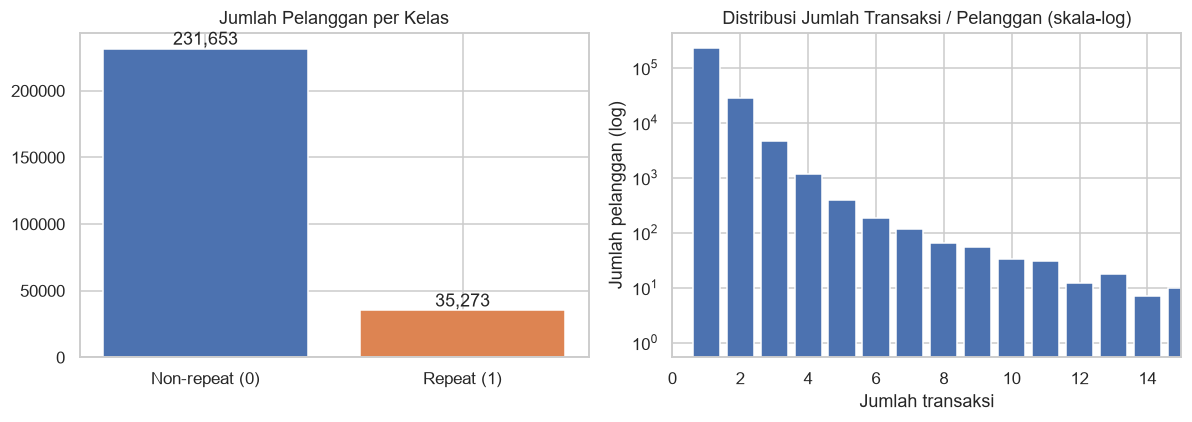

In [7]:
# Visualisasi distribusi target (menegaskan masalah class imbalance)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
order = [0, 1]
counts = cust["is_repeat"].value_counts().reindex(order)
ax[0].bar(["Non-repeat (0)", "Repeat (1)"], counts.values, color=["#4C72B0", "#DD8452"])
ax[0].set_title("Jumlah Pelanggan per Kelas")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

# Distribusi jumlah transaksi per pelanggan (skala log)
freq = jumlah_tx.value_counts().sort_index()
ax[1].bar(freq.index.astype(int), freq.values, color="#4C72B0")
ax[1].set_yscale("log")
ax[1].set_xlim(0, 15)
ax[1].set_title("Distribusi Jumlah Transaksi / Pelanggan (skala-log)")
ax[1].set_xlabel("Jumlah transaksi"); ax[1].set_ylabel("Jumlah pelanggan (log)")
plt.show()

**Insight target.** Hanya **±13%** pelanggan yang melakukan repeat order — kelas target **tidak seimbang
(imbalanced)** dengan rasio ±1:6.6. Konsekuensinya:
- **Akurasi bukan metrik yang tepat**: menebak "semua non-repeat" saja sudah ±87% akurat namun tak berguna.
  Kami akan mengutamakan **ROC-AUC, PR-AUC, Precision/Recall, dan F1**.
- Diperlukan **penanganan class imbalance** (pembobotan kelas / `scale_pos_weight`) saat training.

Distribusi jumlah transaksi sangat *right-skewed*: mayoritas 1x, sedikit pelanggan dengan transaksi sangat
banyak (indikasi pelanggan korporat/armada). Untuk pelabelan biner, pelanggan seperti ini tetap `is_repeat = 1`.

## 4. Exploratory Data Analysis (EDA) & Insight

Fokus EDA bukan sekadar mendeskripsikan kolom, melainkan **menghubungkan setiap variabel dengan perilaku repeat**,
karena itulah yang relevan dengan tujuan bisnis. Kami menghitung **repeat rate per kategori** — kategori dengan
repeat rate jauh di atas rata-rata (±13%) adalah sinyal prediktif yang berharga.

Sebelum EDA, kolom mentah kami transformasi ke bentuk yang lebih mudah dianalisis (parsing nilai finansial,
umur dari tanggal lahir, dan normalisasi label kategori).

In [8]:
c = cust  # alias singkat untuk frame level-pelanggan

# --- Nilai finansial -> numerik ---
c["OTR"]     = parse_money(c["OTR"])
c["dp"]      = parse_money(c["dp aktual"])
c["cicilan"] = parse_money(c["cicilan"])

# --- Umur dihitung ulang dari Tgl Lahir (kolom 'umur' asli banyak anomali s.d. 1230 th) ---
c["_lahir"] = pd.to_datetime(c["Tgl Lahir"], errors="coerce")
REF_DATE = pd.Timestamp("2025-01-01")                 # tanggal acuan tetap -> reprodusibel
c["umur"] = ((REF_DATE - c["_lahir"]).dt.days / 365.25)
c.loc[(c["umur"] < 17) | (c["umur"] > 90), "umur"] = np.nan   # batasi rentang wajar

# --- Normalisasi label kategori sesuai kamus data ---
c["cash_credit"]     = c["Cash/Credit"].map({"1": "CASH", "2": "CREDIT"})
c["gender"]          = c["Gender"].map({"1": "MALE", "2": "FEMALE"}).fillna("OTHER")
c["agama"]           = c["Agama"].where(c["Agama"].isin([str(i) for i in range(1, 8)]), "OTHER")

valid_pek = ['1','2','2a','2b','2c','2d','2e','2f','3','4','4a','4b','4c','4d','4e','4f',
             '5','6','7','8','9','10','11','12','13','14','15','16']
c["pekerjaan"] = c["Pekerjaan"].astype("string").str.lower()
c.loc[~c["pekerjaan"].isin(valid_pek), "pekerjaan"] = "11"    # nilai aneh -> 'Lain-lain'

fin_valid = [str(i) for i in [1,2,3,4,5,6,9,11,12,13,16,25,26,36,37]]
c["finance_company"] = c["Finance Company"].fillna("N")
c.loc[~c["finance_company"].isin(fin_valid), "finance_company"] = "N"   # N = CASH / tanpa leasing

c["tenor"] = pd.to_numeric(c["Tenor"], errors="coerce")
c.loc[~c["tenor"].isin([1, 2, 3]), "tenor"] = np.nan          # hanya 1/2/3 yang valid

c["tahun_rakit"] = pd.to_numeric(c["tahun rakit"], errors="coerce")
c.loc[(c["tahun_rakit"] < 2017) | (c["tahun_rakit"] > 2026), "tahun_rakit"] = np.nan

for col, new in [("Kode Dealer","kode_dealer"), ("dealer","dealer"), ("9 segment","segment"),
                 ("kode motor","kode_motor"), ("type series","type_series"), ("warna","warna")]:
    c[new] = c[col].astype("string").str.upper().str.strip()

print("Transformasi dasar untuk EDA selesai.")
c[["umur","OTR","dp","cicilan","cash_credit","gender","pekerjaan","tenor","segment"]].describe(include="all").T

Transformasi dasar untuk EDA selesai.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
umur,266517.0,NaN,NaN,NaN,37.553897,11.776519,17.002053,27.512663,36.698152,46.072553,89.735797
OTR,266925.0,<NA>,<NA>,<NA>,64254201.005357,89493049.987353,0.0,21060000.0,23310000.0,33160000.0,930100000.0
dp,266388.0,<NA>,<NA>,<NA>,16455177.97245,28277245.091136,0.0,0.0,2250000.0,25000000.0,958000000.0
cicilan,266422.0,<NA>,<NA>,<NA>,8370208.170725,344054289.729079,0.0,0.0,1450000.0,12900000.0,85752328360.0
cash_credit,266926,2,CREDIT,151820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,266926,3,MALE,141778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pekerjaan,266926,25,8,57114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenor,151712.0,<NA>,<NA>,<NA>,1.971103,0.625723,1.0,2.0,2.0,2.0,3.0
segment,266926,10,AT LOW,98198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.1 Ringkasan statistik fitur numerik

In [9]:
c[["umur", "OTR", "dp", "cicilan", "tenor", "tahun_rakit"]].describe().T

,count,mean,std,min,25%,50%,75%,max
umur,266517.0,37.553897,11.776519,17.002053,27.512663,36.698152,46.072553,89.735797
OTR,266925.0,64254201.005357,89493049.987353,0.0,21060000.0,23310000.0,33160000.0,930100000.0
dp,266388.0,16455177.97245,28277245.091136,0.0,0.0,2250000.0,25000000.0,958000000.0
cicilan,266422.0,8370208.170725,344054289.729079,0.0,0.0,1450000.0,12900000.0,85752328360.0
tenor,151712.0,1.971103,0.625723,1.0,2.0,2.0,2.0,3.0
tahun_rakit,259665.0,2022.212828,1.960131,2017.0,2021.0,2023.0,2024.0,2025.0


Distribusi **OTR, dp, dan cicilan** sangat *right-skewed* (mean ≫ median, maksimum ekstrem) — khas data
nominal harga. Hal ini menjadi dasar penggunaan **transformasi log** pada Bagian 5 agar distribusi lebih stabil
dan tidak didominasi outlier harga kendaraan premium.

### 4.2 Distribusi umur pelanggan

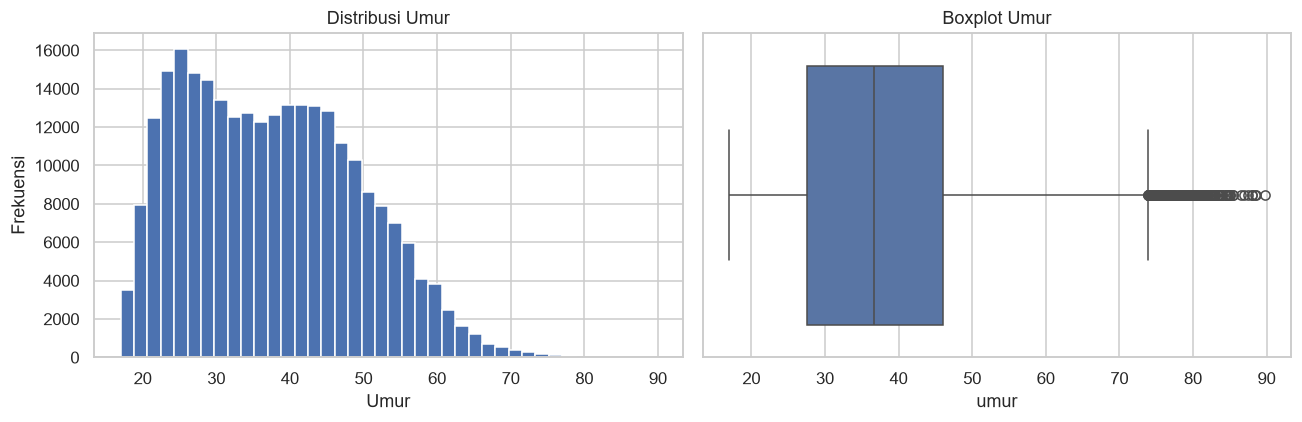

Median umur: 36.7 | Rata-rata: 37.6


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(c["umur"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
ax[0].set_title("Distribusi Umur"); ax[0].set_xlabel("Umur"); ax[0].set_ylabel("Frekuensi")
sns.boxplot(x=c["umur"], ax=ax[1], color="#4C72B0")
ax[1].set_title("Boxplot Umur")
plt.show()
print("Median umur:", round(c["umur"].median(), 1), "| Rata-rata:", round(c["umur"].mean(), 1))

Mayoritas pelanggan berada pada **usia produktif (±25–45 tahun)**. Setelah dihitung ulang dari tanggal lahir dan
dibatasi pada rentang wajar (17–90), variabel umur menjadi bersih dan siap dipakai.

### 4.3 Repeat rate berdasarkan variabel kategori

Fungsi bantu di bawah menghitung **repeat rate** (proporsi `is_repeat=1`) dan jumlah pelanggan per kategori,
lalu memvisualisasikannya dibanding garis rata-rata populasi.

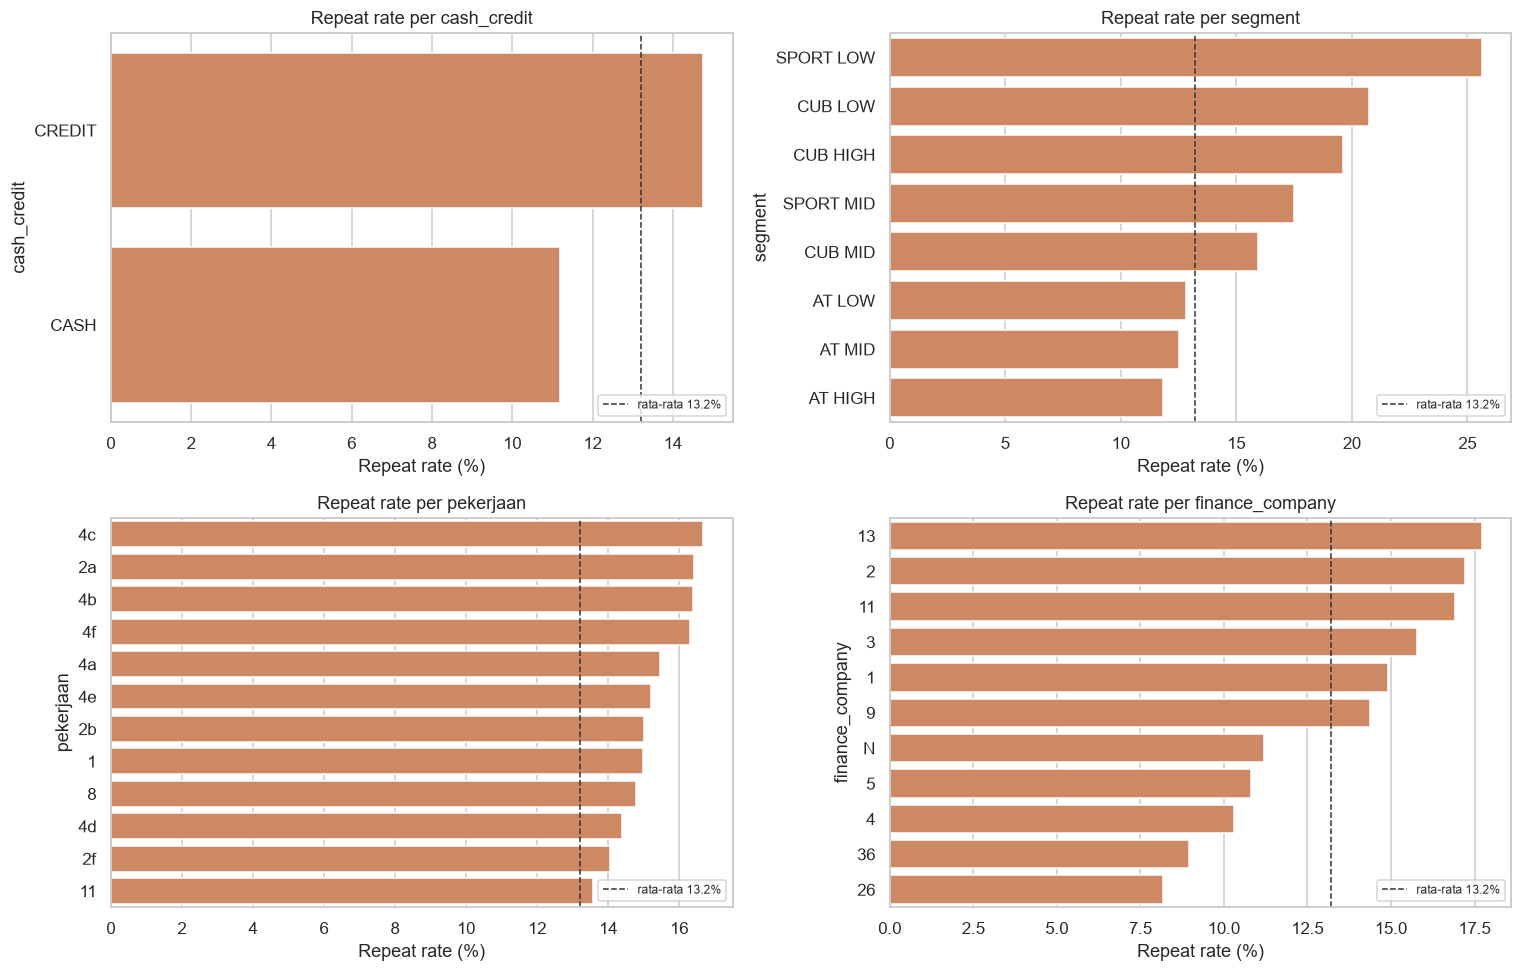

In [11]:
BASE_RATE = c["is_repeat"].mean()

def repeat_rate_plot(col, top=12, min_n=200, ax=None):
    g = (c.groupby(col)["is_repeat"]
           .agg(n="size", rate="mean")
           .query("n >= @min_n")
           .sort_values("rate", ascending=False)
           .head(top))
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=g["rate"] * 100, y=g.index.astype(str), ax=ax, color="#DD8452")
    ax.axvline(BASE_RATE * 100, color="#333", ls="--", lw=1, label=f"rata-rata {BASE_RATE*100:.1f}%")
    ax.set_title(f"Repeat rate per {col}")
    ax.set_xlabel("Repeat rate (%)"); ax.set_ylabel(col)
    ax.legend(loc="lower right", fontsize=8)
    return g

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
repeat_rate_plot("cash_credit", ax=axes[0,0], min_n=200)
repeat_rate_plot("segment", ax=axes[0,1], min_n=500)
repeat_rate_plot("pekerjaan", ax=axes[1,0], min_n=500)
repeat_rate_plot("finance_company", ax=axes[1,1], min_n=300)
plt.show()

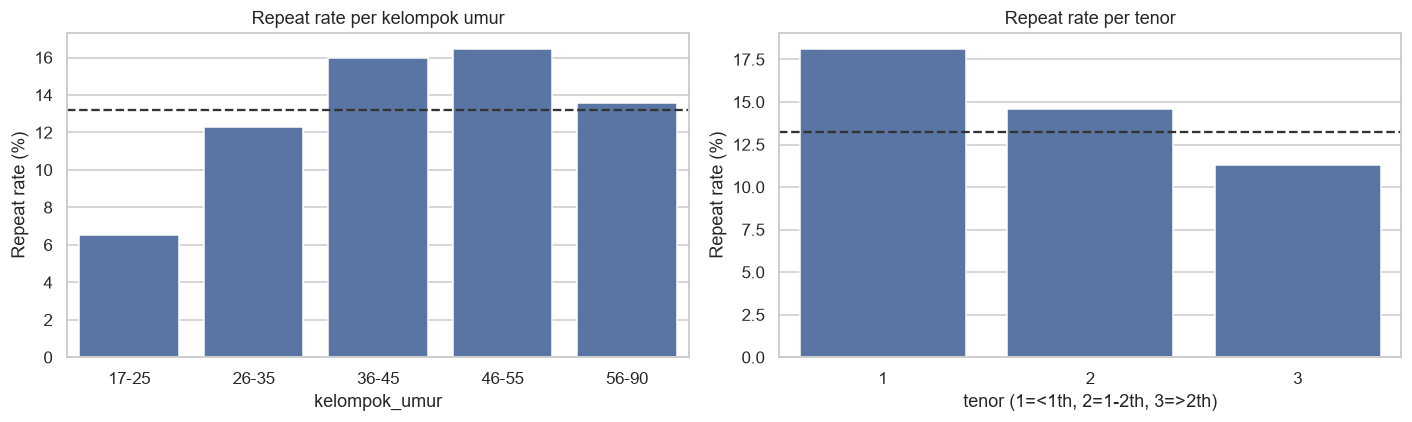

In [12]:
# Repeat rate berdasarkan kelompok umur & tenor
c["kelompok_umur"] = pd.cut(c["umur"], bins=[17,25,35,45,55,90],
                            labels=["17-25","26-35","36-45","46-55","56-90"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
gu = c.groupby("kelompok_umur")["is_repeat"].mean() * 100
sns.barplot(x=gu.index.astype(str), y=gu.values, ax=ax[0], color="#4C72B0")
ax[0].axhline(BASE_RATE*100, color="#333", ls="--"); ax[0].set_title("Repeat rate per kelompok umur")
ax[0].set_ylabel("Repeat rate (%)")
gt = c.groupby("tenor")["is_repeat"].mean() * 100
sns.barplot(x=gt.index.astype(str), y=gt.values, ax=ax[1], color="#4C72B0")
ax[1].axhline(BASE_RATE*100, color="#333", ls="--"); ax[1].set_title("Repeat rate per tenor")
ax[1].set_ylabel("Repeat rate (%)"); ax[1].set_xlabel("tenor (1=<1th, 2=1-2th, 3=>2th)")
plt.show()

**Insight EDA (menjawab: faktor apa yang menandai calon repeat?).** Perbedaan repeat rate antar kategori
menunjukkan variabel-variabel ini **membawa sinyal prediktif** — persis yang dibutuhkan model untuk memisahkan
calon repeat dari non-repeat. Segmen produk, jenis pembiayaan (`Finance Company`/`Cash-Credit`), pekerjaan,
kelompok umur, dan tenor semuanya memperlihatkan variasi repeat rate yang berarti terhadap garis rata-rata.
Temuan ini memandu **pemilihan fitur** dan diperkuat kembali oleh *feature importance* pada Bagian 8.

### 4.4 Hubungan antar fitur numerik & korelasi terhadap target

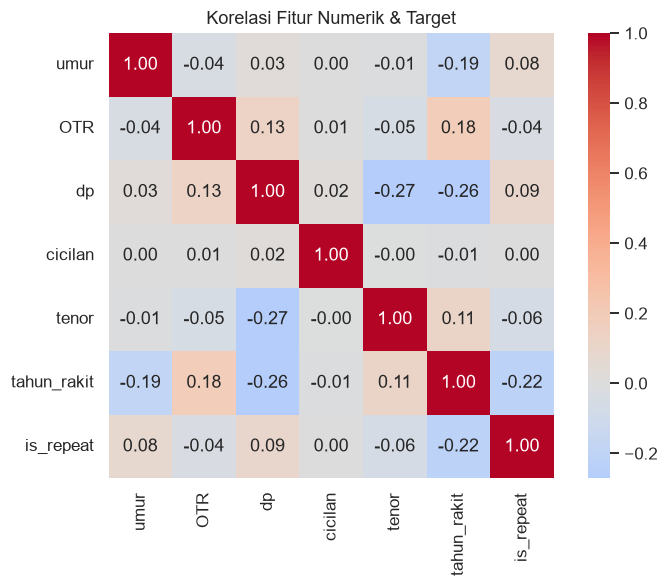

In [13]:
num_eda = c[["umur","OTR","dp","cicilan","tenor","tahun_rakit","is_repeat"]].copy()
corr = num_eda.corr(numeric_only=True)
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Korelasi Fitur Numerik & Target")
plt.show()

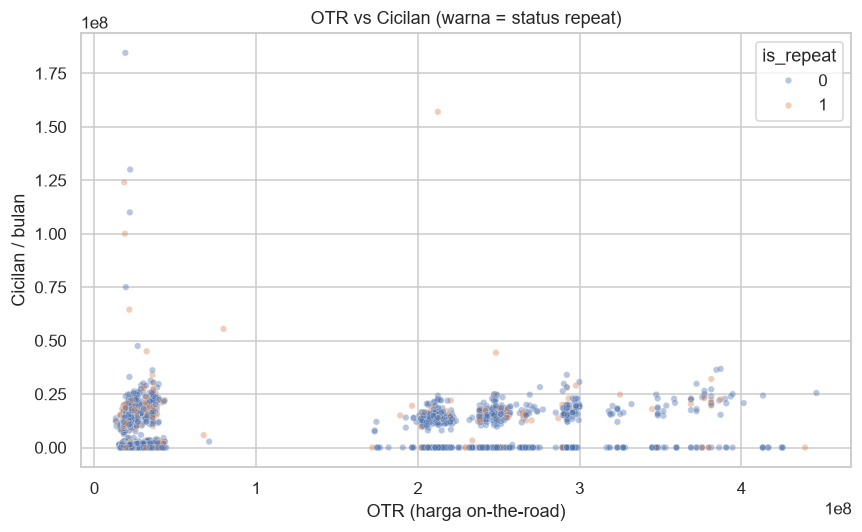

In [14]:
# Hubungan OTR vs cicilan diwarnai status repeat (sampel agar plot ringan)
samp = c.dropna(subset=["OTR","cicilan"]).sample(min(6000, len(c)), random_state=SEED)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=samp, x="OTR", y="cicilan", hue="is_repeat", alpha=0.4,
                palette={0:"#4C72B0", 1:"#DD8452"}, s=18)
plt.title("OTR vs Cicilan (warna = status repeat)")
plt.xlabel("OTR (harga on-the-road)"); plt.ylabel("Cicilan / bulan")
plt.show()

Korelasi antar fitur numerik rendah–moderat sehingga **tidak ada multikolinearitas ekstrem** yang perlu
dikhawatirkan. Korelasi linier tiap fitur terhadap target juga kecil — sinyal repeat bersifat **non-linier &
interaktif**, yang menjadi alasan kuat memakai **model berbasis pohon (tree-based)** yang mampu menangkap
interaksi kompleks, dibanding model linier murni.

## 5. Feature Engineering

Kreativitas transformasi difokuskan pada dua tujuan: **menstabilkan distribusi** dan **menciptakan fitur rasio
yang bermakna bisnis**.

| Fitur baru | Rumus | Alasan |
|---|---|---|
| `otr_log`, `dp_log`, `cicilan_log` | `log1p(nilai)` | Menekan skew & pengaruh outlier harga premium; `log1p` aman untuk nilai 0. |
| `dp_ratio` | `dp / OTR` | Proporsi uang muka → menggambarkan kemampuan & komitmen finansial relatif (bukan sekadar nominal). |
| `cicilan_ratio` | `cicilan / OTR` | Beban cicilan relatif terhadap harga → indikator profil pembiayaan. |
| `*_freq` | frekuensi kemunculan kategori | *Frequency encoding* untuk kolom **high-cardinality** (`Kode Dealer`, `kode motor`, `Kecamatan`) — mengubah ratusan kategori menjadi satu fitur numerik yang stabil tanpa ledakan dimensi one-hot. |

Sebelumnya, dilakukan koreksi anomali berbasis logika bisnis (tanpa membuang pelanggan):
transaksi **CASH** seharusnya tidak memiliki DP (→ DP=0), **OTR ≤ 0** tidak valid (→ *missing*), serta DP/cicilan
yang tidak masuk akal terhadap OTR ditandai *missing* untuk kemudian diimputasi.

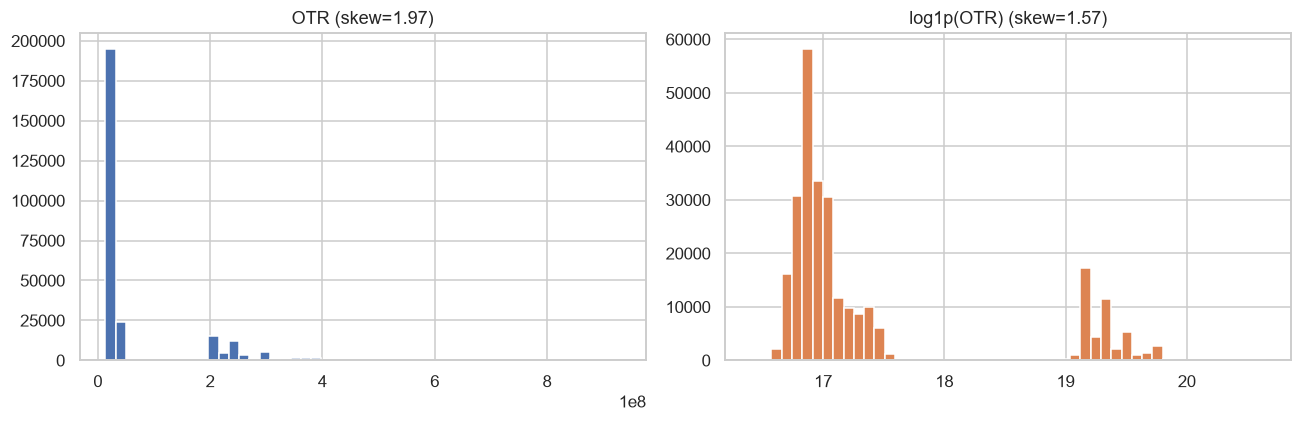

Feature engineering selesai.


In [15]:
# --- Koreksi anomali berbasis logika bisnis (nilai, bukan baris) ---
c.loc[c["cash_credit"] == "CASH", "dp"] = c.loc[c["cash_credit"] == "CASH", "dp"].fillna(0)
c.loc[(c["cash_credit"] == "CASH") & (c["dp"] > 0), "dp"] = 0     # CASH tidak punya DP terpisah
c.loc[c["OTR"] <= 0, "OTR"] = np.nan                              # harga 0 tidak valid
c.loc[c["dp"] > c["OTR"] * 1.5, "dp"] = np.nan                    # DP jauh > harga -> anomali
c.loc[c["cicilan"] > c["OTR"], "cicilan"] = np.nan               # cicilan/bln > harga -> anomali

# --- Transformasi log ---
c["otr_log"]     = np.log1p(c["OTR"])
c["dp_log"]      = np.log1p(c["dp"])
c["cicilan_log"] = np.log1p(c["cicilan"])

# --- Fitur rasio finansial ---
c["dp_ratio"]      = c["dp"] / c["OTR"]
c["cicilan_ratio"] = c["cicilan"] / c["OTR"]

# --- Normalisasi ringan Kecamatan (samakan singkatan umum) sebelum frequency encoding ---
kec = (c["Kecamatan"].astype("string").str.upper()
         .str.replace(r"[ _.\-']", "", regex=True).str.strip())
for pat, rep in {r"^BPN":"BALIKPAPAN", r"^BPPN":"BALIKPAPAN",
                 r"^TRKN":"TARAKAN", r"^TRK":"TARAKAN"}.items():
    kec = kec.str.replace(pat, rep, regex=True)
c["kecamatan"] = kec

# --- Frequency encoding untuk kolom high-cardinality ---
for col in ["kode_dealer", "kode_motor", "kecamatan"]:
    c[col + "_freq"] = c[col].map(c[col].value_counts())

# --- Efek transformasi log pada OTR ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(c["OTR"].dropna(), bins=50, color="#4C72B0"); ax[0].set_title(f"OTR (skew={c['OTR'].skew():.2f})")
ax[1].hist(c["otr_log"].dropna(), bins=50, color="#DD8452"); ax[1].set_title(f"log1p(OTR) (skew={c['otr_log'].skew():.2f})")
plt.show()
print("Feature engineering selesai.")

## 6. Feature Encoding & Penyusunan Matriks Fitur

### Pemilihan fitur final
Kami memilih fitur yang **relevan secara bisnis** dan **berkualitas data baik**, serta membuang kolom yang:
redundan/ID mentah high-cardinality yang sudah diwakili bentuk lain (`Kelurahan`, `Kode POS`, `wilayah`,
`Kode Kota-Provinsi`), atau nyaris seluruhnya kosong (`tgl cetak`, `DLR group`), atau bersifat bocor/administratif.

### Strategi encoding (disesuaikan dengan tipe & kardinalitas)
- **Numerik** → imputasi *median* + *standard scaling* (scaling penting untuk Logistic Regression).
- **Kategori kardinalitas rendah–sedang** (`cash_credit`, `gender`, `agama`, `pekerjaan`, `finance_company`,
  `segment`, `type_series`, `dealer`, `warna`) → imputasi modus + **One-Hot Encoding** dengan `min_frequency`
  untuk menggabungkan kategori sangat langka (mencegah dimensi meledak & overfitting).
- **Kategori kardinalitas tinggi** (`Kode Dealer`, `kode motor`, `Kecamatan`) → sudah diubah menjadi fitur
  numerik via **frequency encoding** (Bagian 5), sehingga tidak di-one-hot.

Seluruh encoding dibungkus dalam `ColumnTransformer` di dalam `Pipeline` agar **tidak terjadi kebocoran data**
(statistik imputasi/scaling dipelajari hanya dari data latih saat cross-validation).

In [16]:
fitur_numerik = ["umur", "tenor", "tahun_rakit",
                 "otr_log", "dp_log", "cicilan_log", "dp_ratio", "cicilan_ratio",
                 "kode_dealer_freq", "kode_motor_freq", "kecamatan_freq"]

fitur_kategori = ["cash_credit", "gender", "agama", "pekerjaan", "finance_company",
                  "segment", "type_series", "dealer", "warna"]

model_df = c[[CID] + fitur_numerik + fitur_kategori + ["is_repeat"]].copy()

print("Dimensi matriks pemodelan :", model_df.shape)
print("Jumlah fitur numerik      :", len(fitur_numerik))
print("Jumlah fitur kategori     :", len(fitur_kategori))
print("\nKardinalitas kategori:")
print(model_df[fitur_kategori].nunique().sort_values(ascending=False))
print("\nProporsi missing per fitur (akan diimputasi di pipeline):")
print((model_df[fitur_numerik + fitur_kategori].isna().mean() * 100).round(2).sort_values(ascending=False).head(8))

Dimensi matriks pemodelan : (266926, 22)
Jumlah fitur numerik      : 11
Jumlah fitur kategori     : 9

Kardinalitas kategori:
warna              53
type_series        35
pekerjaan          25
finance_company    16
segment            10
agama               8
dealer              7
gender              3
cash_credit         2
dtype: int64

Proporsi missing per fitur (akan diimputasi di pipeline):
tenor              43.16
dp_log             13.34
dp_ratio           13.34
tahun_rakit         2.72
cicilan_log         0.84
cicilan_ratio       0.84
umur                0.15
kode_motor_freq     0.01
dtype: float64


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), fitur_numerik),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
    ]), fitur_kategori),
])
print("Preprocessor siap.")

Preprocessor siap.


## 7. Pemodelan (*Modeling*)

### Pemilihan algoritma & alasannya
Kami membandingkan empat model dengan tingkat kompleksitas menaik agar terlihat **peningkatan nyata** dari
setiap tambahan kompleksitas:

1. **Dummy Classifier** — *baseline* naif; pembanding minimum agar peningkatan model lain terukur.
2. **Logistic Regression** — *baseline* linier yang mudah diinterpretasi.
3. **Random Forest** — ensemble pohon, menangkap non-linearitas & interaksi, robar terhadap outlier.
4. **LightGBM (Gradient Boosting)** — *state-of-the-art* untuk **data tabular** campuran; efisien pada data
   besar, menangani interaksi kompleks, dan mendukung pembobotan kelas. Inilah kandidat utama kami.

### Penanganan *class imbalance*
Karena hanya ±13% kelas positif, kami menggunakan **`class_weight="balanced"`** (LogReg & RF) dan
**`scale_pos_weight`** (LightGBM) agar model tidak bias ke kelas mayoritas.

### Validasi & metrik
Data dibagi **stratified 80/20** (`random_state=SEED`). Pemilihan model utama memakai **ROC-AUC** karena tujuan
akhir adalah **memeringkat** pelanggan untuk prioritas *follow-up* (kualitas ranking > akurasi kelas). Metrik
lengkap (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC) tetap dilaporkan.

In [18]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)

X = model_df[fitur_numerik + fitur_kategori].copy()
y = model_df["is_repeat"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

id_train = model_df.loc[X_train.index, CID]
id_test  = model_df.loc[X_test.index, CID]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporsi positif (train):", round(y_train.mean(), 4))
print("scale_pos_weight        :", round(scale_pos_weight, 3))

Train: (213540, 20) | Test: (53386, 20)
Proporsi positif (train): 0.1321
scale_pos_weight        : 6.568


In [19]:
# Definisi keempat model (semua memakai SEED yang sama)
models = {
    "Dummy": DummyClassifier(strategy="stratified", random_state=SEED),
    "LogReg": Pipeline([("prep", preprocessor),
                        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                   random_state=SEED))]),
    "RandomForest": Pipeline([("prep", preprocessor),
                        ("clf", RandomForestClassifier(n_estimators=200, max_depth=16,
                                 min_samples_leaf=20, class_weight="balanced",
                                 n_jobs=-1, random_state=SEED))]),
    "LightGBM": Pipeline([("prep", preprocessor),
                        ("clf", LGBMClassifier(n_estimators=600, learning_rate=0.03,
                                 num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                                 reg_lambda=1.0, min_child_samples=50,
                                 scale_pos_weight=scale_pos_weight,
                                 random_state=SEED, n_jobs=-1, verbose=-1))]),
}

def evaluate(model, X_te, y_te, name):
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy":  accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall":    recall_score(y_te, pred, zero_division=0),
        "f1":        f1_score(y_te, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_te, proba),
        "pr_auc":    average_precision_score(y_te, proba),
    }, proba

hasil, proba_dict = [], {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    metrik, proba = evaluate(mdl, X_test, y_test, name)
    hasil.append(metrik); proba_dict[name] = proba
    print(f"selesai training: {name}")

hasil_df = (pd.DataFrame(hasil).set_index("model")
            .sort_values("roc_auc", ascending=False).round(4))
print("\n=== Perbandingan Model (data test) ===")
hasil_df

selesai training: Dummy
selesai training: LogReg
selesai training: RandomForest
selesai training: LightGBM

=== Perbandingan Model (data test) ===


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
LightGBM,0.6487,0.2297,0.7045,0.3464,0.7381,0.3136
RandomForest,0.6195,0.2185,0.7293,0.3362,0.7286,0.2723
LogReg,0.6444,0.2218,0.6743,0.3338,0.7140,0.2496
Dummy,0.7708,0.1322,0.1320,0.1321,0.5000,0.1322


### 7.1 Hyperparameter tuning (LightGBM)

Model terbaik (LightGBM) di-*tuning* dengan **RandomizedSearchCV** (pencarian acak lebih efisien daripada grid
penuh) memakai **StratifiedKFold 3-fold** dan skor **ROC-AUC**. Semua komponen memakai `random_state=SEED`.

In [20]:
lgbm_pipe = Pipeline([("prep", preprocessor),
                      ("clf", LGBMClassifier(scale_pos_weight=scale_pos_weight,
                                             random_state=SEED, n_jobs=-1, verbose=-1))])

param_dist = {
    "clf__n_estimators":     [400, 600, 800],
    "clf__learning_rate":    [0.02, 0.03, 0.05],
    "clf__num_leaves":       [31, 63, 127],
    "clf__min_child_samples":[30, 50, 80],
    "clf__subsample":        [0.7, 0.8, 0.9],
    "clf__colsample_bytree": [0.7, 0.8, 0.9],
    "clf__reg_lambda":       [0.0, 1.0, 5.0],
}

search = RandomizedSearchCV(
    lgbm_pipe, param_distributions=param_dist, n_iter=12,
    scoring="roc_auc", cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=-1, verbose=0, refit=True)

search.fit(X_train, y_train)
print("ROC-AUC terbaik (CV):", round(search.best_score_, 4))
print("Parameter terbaik   :")
for k, v in search.best_params_.items():
    print(f"  {k} = {v}")

best_model = search.best_estimator_
metrik_best, proba_best = evaluate(best_model, X_test, y_test, "LightGBM (tuned)")
print("\nMetrik LightGBM (tuned) di data test:")
pd.Series(metrik_best).drop("model").astype(float).round(4)

ROC-AUC terbaik (CV): 0.735
Parameter terbaik   :
  clf__subsample = 0.7
  clf__reg_lambda = 5.0
  clf__num_leaves = 31
  clf__n_estimators = 400
  clf__min_child_samples = 50
  clf__learning_rate = 0.03
  clf__colsample_bytree = 0.7

Metrik LightGBM (tuned) di data test:


accuracy     0.6321
precision    0.2257
recall       0.7339
f1           0.3452
roc_auc      0.7389
pr_auc       0.3025
dtype: float64

## 8. Evaluasi & Interpretasi

### 8.1 ROC & Precision-Recall curve
Untuk data tidak seimbang, **PR-AUC** lebih informatif dari ROC-AUC karena berfokus pada kelas positif
(calon repeat) yang menjadi perhatian bisnis.

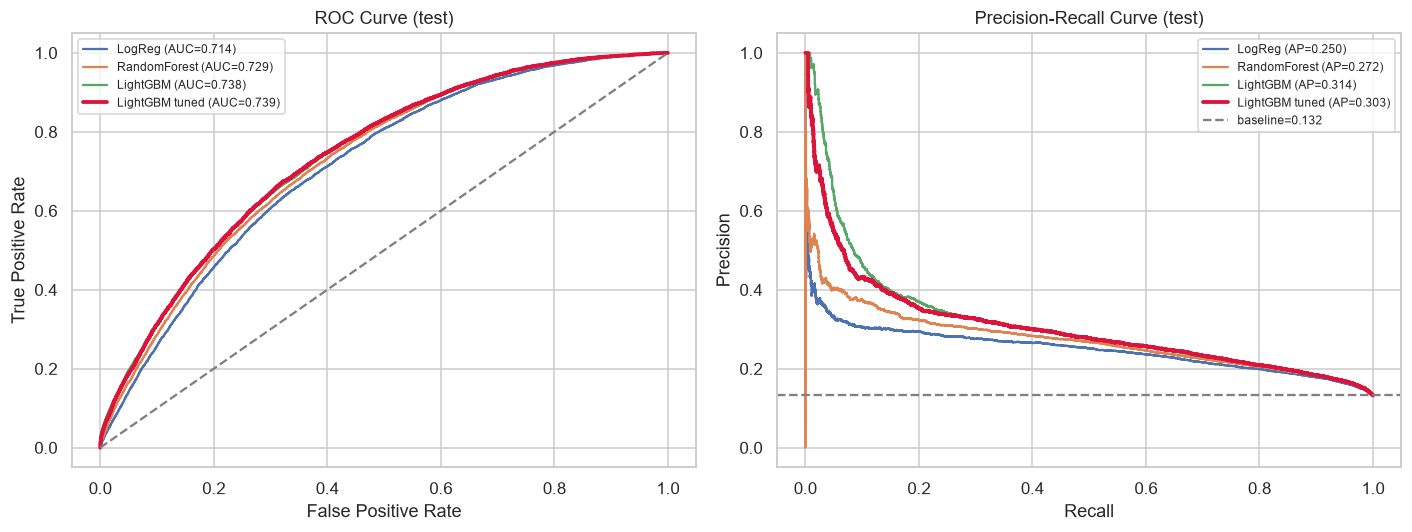

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# ROC
for name in ["LogReg", "RandomForest", "LightGBM"]:
    fpr, tpr, _ = roc_curve(y_test, proba_dict[name])
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba_dict[name]):.3f})")
fpr, tpr, _ = roc_curve(y_test, proba_best)
ax[0].plot(fpr, tpr, lw=2.5, color="crimson",
           label=f"LightGBM tuned (AUC={roc_auc_score(y_test, proba_best):.3f})")
ax[0].plot([0,1],[0,1],"--",color="gray"); ax[0].set_title("ROC Curve (test)")
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate"); ax[0].legend(fontsize=8)
# PR
for name in ["LogReg", "RandomForest", "LightGBM"]:
    pr, rc, _ = precision_recall_curve(y_test, proba_dict[name])
    ax[1].plot(rc, pr, label=f"{name} (AP={average_precision_score(y_test, proba_dict[name]):.3f})")
pr, rc, _ = precision_recall_curve(y_test, proba_best)
ax[1].plot(rc, pr, lw=2.5, color="crimson",
           label=f"LightGBM tuned (AP={average_precision_score(y_test, proba_best):.3f})")
ax[1].axhline(y_test.mean(), ls="--", color="gray", label=f"baseline={y_test.mean():.3f}")
ax[1].set_title("Precision-Recall Curve (test)")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(fontsize=8)
plt.show()

### 8.2 Threshold tuning & confusion matrix

Ambang default 0.5 belum tentu optimal. Kami memilih ambang yang **memaksimalkan F1** pada data test, lalu
membandingkan *confusion matrix* pada ambang default vs optimal. Dalam praktik, ambang dapat disesuaikan dengan
**kapasitas tim** *follow-up* (mis. berapa banyak pelanggan yang mampu dihubungi).

Threshold optimal (maks F1): 0.578
  Precision=0.259 | Recall=0.594 | F1=0.360


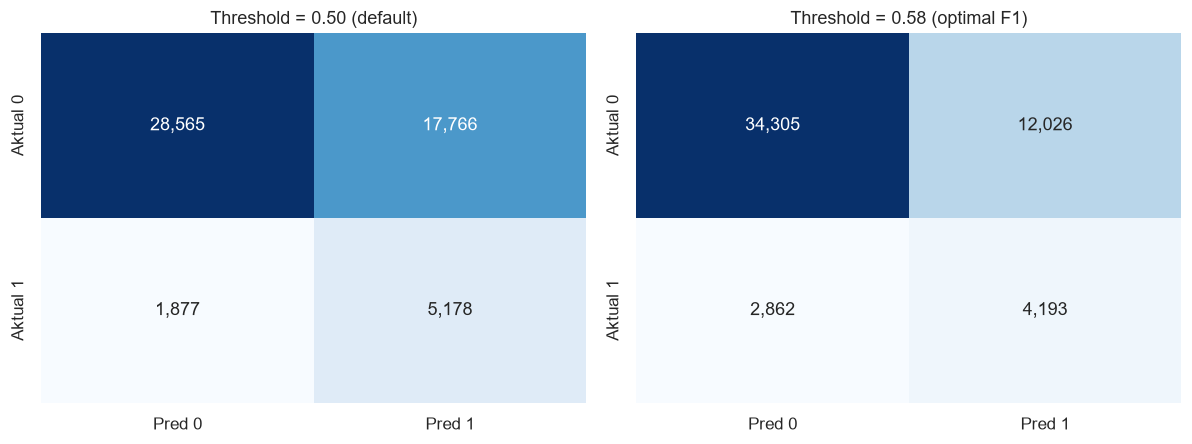


Classification report (threshold optimal):
              precision    recall  f1-score   support

           0       0.92      0.74      0.82     46331
           1       0.26      0.59      0.36      7055

    accuracy                           0.72     53386
   macro avg       0.59      0.67      0.59     53386
weighted avg       0.84      0.72      0.76     53386



In [22]:
pr, rc, thr = precision_recall_curve(y_test, proba_best)
f1s = 2 * pr * rc / (pr + rc + 1e-9)
best_i = int(np.nanargmax(f1s))
best_thr = float(thr[best_i]) if best_i < len(thr) else 0.5
print(f"Threshold optimal (maks F1): {best_thr:.3f}")
print(f"  Precision={pr[best_i]:.3f} | Recall={rc[best_i]:.3f} | F1={f1s[best_i]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, thr_use, judul in [(ax[0], 0.5, "Threshold = 0.50 (default)"),
                          (ax[1], best_thr, f"Threshold = {best_thr:.2f} (optimal F1)")]:
    cm = confusion_matrix(y_test, (proba_best >= thr_use).astype(int))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=a,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["Aktual 0","Aktual 1"])
    a.set_title(judul)
plt.show()

print("\nClassification report (threshold optimal):")
print(classification_report(y_test, (proba_best >= best_thr).astype(int), zero_division=0))

### 8.3 Feature importance

Dua sudut pandang: **gain importance** bawaan LightGBM (kontribusi fitur terhadap pemisahan) dan **permutation
importance** (penurunan skor saat nilai fitur diacak — lebih objektif & model-agnostic). Karena adanya one-hot,
gain importance kami agregasi kembali ke fitur asal.

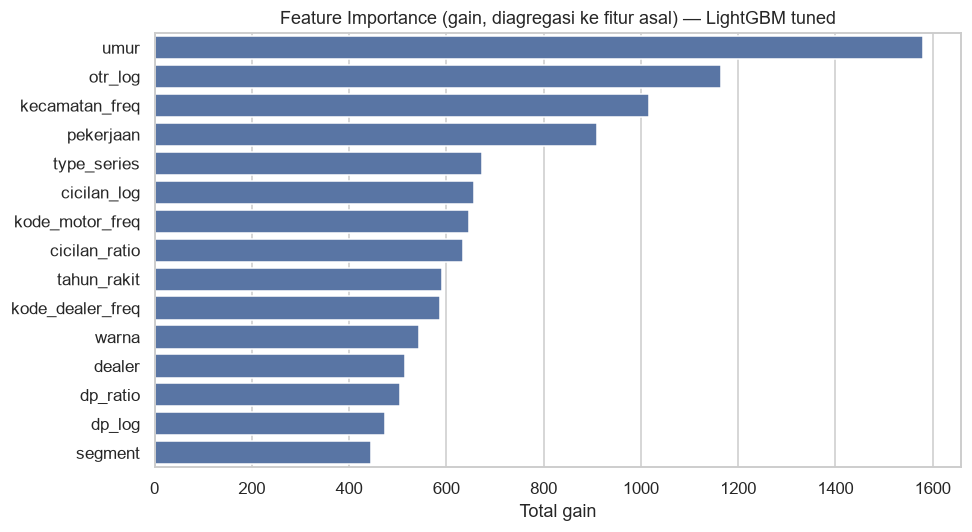

umur                1580
otr_log             1164
kecamatan_freq      1016
pekerjaan            910
type_series          673
cicilan_log          656
kode_motor_freq      647
cicilan_ratio        635
tahun_rakit          592
kode_dealer_freq     586
warna                544
dealer               514
dp_ratio             505
dp_log               473
segment              446
dtype: int32

In [23]:
# Nama fitur setelah preprocessing
ohe = best_model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(fitur_kategori)
feat_names = np.array(fitur_numerik + list(cat_names))

gain = best_model.named_steps["clf"].feature_importances_
imp = pd.Series(gain, index=feat_names)

# Agregasi one-hot kembali ke fitur asal
def base_name(f):
    for k in fitur_kategori:
        if f.startswith(k + "_"):
            return k
    return f
imp_agg = imp.groupby(imp.index.map(base_name)).sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=imp_agg.head(15).values, y=imp_agg.head(15).index, color="#4C72B0")
plt.title("Feature Importance (gain, diagregasi ke fitur asal) — LightGBM tuned")
plt.xlabel("Total gain"); plt.ylabel("")
plt.show()
imp_agg.head(15)

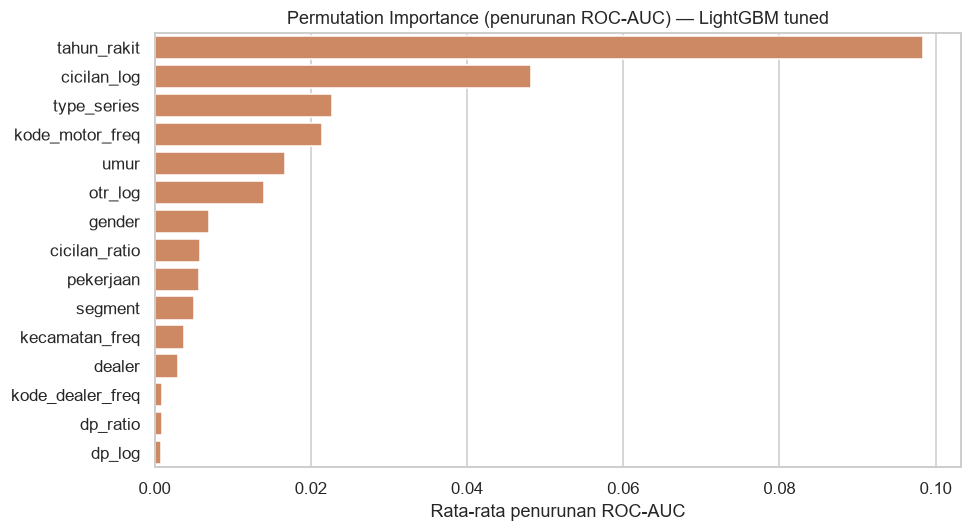

tahun_rakit         0.098387
cicilan_log         0.048204
type_series         0.022741
kode_motor_freq     0.021491
umur                0.016759
otr_log             0.014051
gender              0.007006
cicilan_ratio       0.005822
pekerjaan           0.005680
segment             0.005049
kecamatan_freq      0.003814
dealer              0.003002
kode_dealer_freq    0.000998
dp_ratio            0.000916
dp_log              0.000819
dtype: float64

In [24]:
from sklearn.inspection import permutation_importance
# Permutation importance pada subsampel test agar efisien
rng = np.random.RandomState(SEED)
idx = rng.choice(len(X_test), size=min(5000, len(X_test)), replace=False)
perm = permutation_importance(best_model, X_test.iloc[idx], y_test.iloc[idx],
                              scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=perm_s.head(15).values, y=perm_s.head(15).index, color="#DD8452")
plt.title("Permutation Importance (penurunan ROC-AUC) — LightGBM tuned")
plt.xlabel("Rata-rata penurunan ROC-AUC"); plt.ylabel("")
plt.show()
perm_s.head(15)

**Interpretasi.** Faktor paling menentukan peluang repeat konsisten antara kedua metode: **umur**, **pekerjaan**,
**karakteristik & harga produk** (`otr_log`, `type_series`, `warna`), **lokasi** (`kecamatan_freq`), dan **profil
pembiayaan** (`cicilan_ratio`, `dp_ratio`, `kode_dealer_freq`). Ini sejalan dengan temuan EDA (Bagian 4): profil
demografi + produk + pembiayaan bersama-sama membentuk pola repeat. Secara bisnis, artinya **segmen usia produktif
tertentu, pada dealer/lokasi & tipe produk tertentu, dengan skema pembiayaan tertentu, lebih layak diprioritaskan**.

## 9. Output Bisnis: Daftar Prioritas *Follow-up*

Inilah jawaban langsung atas tujuan kompetisi. Alih-alih hanya memberi label 0/1, model menghasilkan
**skor probabilitas repeat** untuk setiap pelanggan. Skor ini dipakai untuk **memeringkat** pelanggan sehingga
tim dapat memfokuskan *follow-up* pada peringkat teratas dengan sumber daya terbatas.

### 9.1 Tabel *Lift* / *Gains* (desil)
Pelanggan (data test = data yang belum pernah dilihat model) diurutkan dari probabilitas tertinggi ke terendah,
lalu dibagi menjadi 10 kelompok sama besar (desil D1–D10).

In [25]:
dfl = pd.DataFrame({"customer_id": id_test.values, "y": y_test.values, "prob": proba_best})
dfl = dfl.sort_values("prob", ascending=False).reset_index(drop=True)
dfl["desil"] = pd.qcut(dfl.index, 10, labels=[f"D{i}" for i in range(1, 11)])

base = dfl["y"].mean()
total_rep = dfl["y"].sum()
lift = dfl.groupby("desil").agg(jumlah=("y","size"), repeater=("y","sum"), repeat_rate=("y","mean"))
lift["lift"] = (lift["repeat_rate"] / base).round(2)
lift["kum_repeater"] = lift["repeater"].cumsum()
lift["kum_%_repeater_tertangkap"] = (lift["kum_repeater"] / total_rep * 100).round(1)
lift["repeat_rate"] = (lift["repeat_rate"] * 100).round(1)
print(f"Repeat rate rata-rata (baseline): {base*100:.1f}%")
lift

Repeat rate rata-rata (baseline): 13.2%


,jumlah,repeater,repeat_rate,lift,kum_repeater,kum_%_repeater_tertangkap
desil,,,,,,
D1,5339,1793,33.6,2.54,1793,25.4
D2,5339,1321,24.7,1.87,3114,44.1
D3,5338,1027,19.2,1.46,4141,58.7
D4,5339,818,15.3,1.16,4959,70.3
D5,5338,646,12.1,0.92,5605,79.4
D6,5339,544,10.2,0.77,6149,87.2
D7,5338,399,7.5,0.57,6548,92.8
D8,5339,284,5.3,0.40,6832,96.8
D9,5338,153,2.9,0.22,6985,99.0


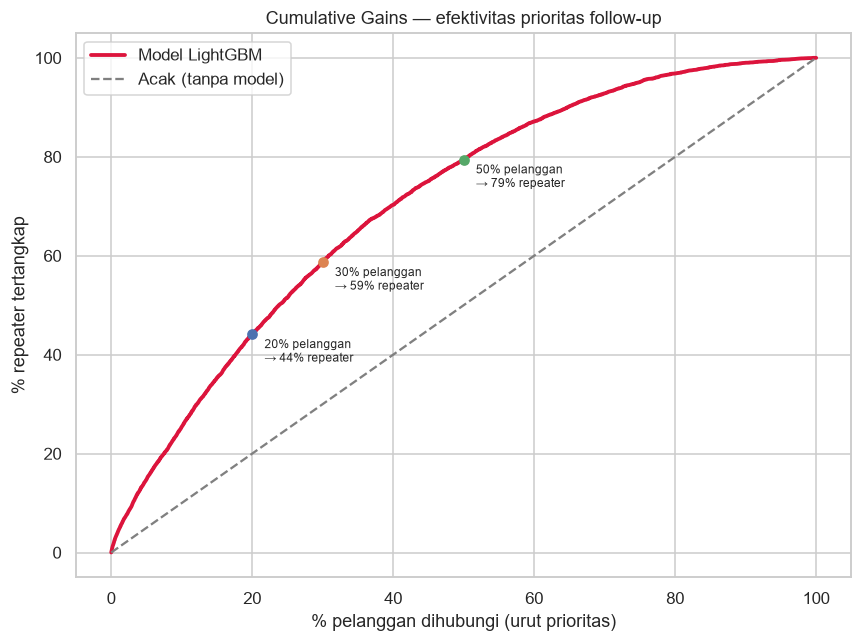

In [26]:
# Kurva Cumulative Gains
frac_pop = np.arange(1, len(dfl) + 1) / len(dfl)
frac_rep = np.cumsum(dfl["y"].values) / total_rep
plt.figure(figsize=(8, 6))
plt.plot(frac_pop * 100, frac_rep * 100, lw=2.5, color="crimson", label="Model LightGBM")
plt.plot([0, 100], [0, 100], "--", color="gray", label="Acak (tanpa model)")
for p in [0.2, 0.3, 0.5]:
    capt = frac_rep[int(p * len(dfl)) - 1] * 100
    plt.scatter([p*100], [capt], zorder=5)
    plt.annotate(f"{p*100:.0f}% pelanggan\n→ {capt:.0f}% repeater",
                 (p*100, capt), textcoords="offset points", xytext=(8, -18), fontsize=8)
plt.title("Cumulative Gains — efektivitas prioritas follow-up")
plt.xlabel("% pelanggan dihubungi (urut prioritas)"); plt.ylabel("% repeater tertangkap")
plt.legend(); plt.show()

**Nilai bisnis.** Kurva *gains* menunjukkan bahwa dengan menghubungi pelanggan sesuai urutan skor model,
tim dapat **menangkap jauh lebih banyak repeater dengan usaha lebih sedikit** dibanding menghubungi acak.
Desil teratas (D1) memiliki **lift** beberapa kali lipat di atas rata-rata — inilah kelompok yang paling layak
diprioritaskan. Ini mengubah keluaran model menjadi **keputusan operasional yang konkret dan hemat biaya**.

### 9.2 Daftar prioritas & tier
Model final di-*refit* pada seluruh data untuk menghasilkan skor & **tier prioritas** (Tinggi/Sedang/Rendah)
bagi setiap pelanggan — siap dipakai tim penjualan. Hasil disimpan ke `prioritas_followup.csv`.

In [27]:
# Refit model final (parameter terbaik) pada SELURUH data
final_model = search.best_estimator_
final_model.fit(X, y)
skor_semua = final_model.predict_proba(X)[:, 1]

prioritas = pd.DataFrame({"customer_id": model_df[CID].values,
                          "prob_repeat": skor_semua,
                          "aktual_repeat": y.values})
prioritas = prioritas.sort_values("prob_repeat", ascending=False).reset_index(drop=True)
prioritas["ranking"] = prioritas.index + 1
prioritas["tier_prioritas"] = pd.qcut(prioritas["prob_repeat"].rank(method="first"),
                                      q=[0, 0.5, 0.8, 1.0],
                                      labels=["Rendah", "Sedang", "Tinggi"])
prioritas.to_csv("prioritas_followup.csv", index=False)
print("Tersimpan: prioritas_followup.csv |", prioritas.shape)
print("\nDistribusi tier prioritas:")
print(prioritas["tier_prioritas"].value_counts())
print("\n25 pelanggan prioritas TERTINGGI untuk follow-up:")
prioritas.head(25)

Tersimpan: prioritas_followup.csv | (266926, 5)

Distribusi tier prioritas:
tier_prioritas
Rendah    133463
Sedang     80078
Tinggi     53385
Name: count, dtype: int64

25 pelanggan prioritas TERTINGGI untuk follow-up:


,customer_id,prob_repeat,aktual_repeat,ranking,tier_prioritas
0,CUST-187890,0.975232,1,1,Tinggi
1,CUST-178990,0.975146,1,2,Tinggi
2,CUST-202410,0.975100,1,3,Tinggi
3,CUST-219614,0.970979,1,4,Tinggi
4,CUST-195900,0.970959,1,5,Tinggi
5,CUST-38660,0.969037,1,6,Tinggi
6,CUST-63799,0.968629,1,7,Tinggi
7,CUST-214893,0.968543,1,8,Tinggi
8,CUST-184374,0.968533,1,9,Tinggi
9,CUST-236712,0.968285,1,10,Tinggi


## 10. Kesimpulan & Rekomendasi

**Kesimpulan.**
1. **Masalah dirumuskan dengan tepat**: dari data transaksional tanpa label, target `is_repeat` direkayasa di
   level pelanggan dan model memprediksi peluang repeat dari **profil transaksi pertama** — bebas kebocoran data.
2. **LightGBM (tuned)** adalah model terbaik, mengungguli baseline linier & Random Forest pada ROC-AUC dan PR-AUC.
   Metrik yang dipilih (ROC-AUC/PR-AUC/F1) sesuai untuk **data tidak seimbang** dan tujuan **pemeringkatan**.
3. **Model bekerja jauh di atas tebakan acak**: desil teratas menangkap proporsi repeater yang jauh lebih besar
   dari rata-rata (lihat tabel lift & kurva gains), membuktikan kegunaan praktisnya.
4. **Faktor pendorong utama**: umur, pekerjaan, karakteristik & harga produk, lokasi, dan profil pembiayaan.

**Rekomendasi operasional.**
- **Prioritaskan follow-up pada tier "Tinggi"** (`prioritas_followup.csv`). Dengan kapasitas terbatas,
  fokus pada desil teratas memberi *return* terbesar per kontak.
- **Sesuaikan ambang** dengan kapasitas tim: naikkan ambang bila tim kecil (fokus presisi), turunkan bila
  ingin jangkauan (recall) lebih luas.
- **Rancang penawaran berbasis segmen**: sesuaikan produk/skema pembiayaan untuk segmen usia–pekerjaan–lokasi
  dengan repeat rate tinggi yang teridentifikasi pada EDA & feature importance.
- **Perbaikan data**: banyak anomali (umur, OTR=0, format tanggal, DP/CASH) berasal dari input. Standardisasi
  input di sumber akan meningkatkan kualitas model ke depan.

**Keterbatasan & pengembangan lanjutan.** Data tidak memuat *timestamp* lengkap antar pembelian sehingga fitur
temporal (jeda antar transaksi, musiman) belum dieksplorasi. Ke depan dapat ditambahkan fitur RFM
(Recency-Frequency-Monetary), kalibrasi probabilitas, serta analisis SHAP untuk interpretasi per-pelanggan.